# WM 2026 Match Predictor – Datenanalyse & Modell-Evaluation

Datenpipeline-Status, EDA, Feature-Auswahl und Modell-Evaluation.
Voraussetzung: `fetch_data.py`, `fetch_match_stats.py`, `build_features.py`, `train_model.py` bereits ausgeführt.


#### **Datenquellen**

| Quelle | Speicherort | Inhalt |
|---|---|---|
| API-Football | `data/raw/fixtures_*.json` | Länderspiele 2018–2026 pro Team |
| API-Football | `data/raw/stats/{id}.json` | Ballbesitz, Schüsse, Ecken pro Spiel |
| Kaggle Ranking-Ratings | `data/raw/elo_ratings_wc2026.csv` | Ranking-Rating pro Team/Jahr, 1901–2026 (Elo-basiert) |
| `build_features.py` | `data/processed/match_features.csv` | Feature-Tabelle (1 Zeile/Spiel) |


#### **Features**

Alle Features nur aus Daten **vor** dem Spieldatum (kein Leakage). `a_*`/`b_*` = Team A/B.

| Kategorie | Spalten | Bedeutung |
|---|---|---|
| Meta | `fixture_id`, `date`, `team_a/b`, `result` | Identifikatoren + Zielvariable (A/Draw/B) |
| Form (Ø letzte 5 Spiele) | `*_form_points`, `*_goals_for_avg`, `*_goals_against_avg` | Punkte, Tore, Gegentore |
| Match-Stats (Ø letzte 5) | `*_possession_avg`, `*_shots_total_avg`, `*_shots_on_goal_avg`, `*_corners_avg` | Ballbesitz, Schüsse, Ecken |
| H2H | `h2h_games`, `h2h_a_wins/draws/losses` | Direkter Vergleich A vs. B |
| Ranking | `ranking_a`, `ranking_b`, `ranking_diff` | Team-Stärke im Spieljahr (stärkstes Feature) |

`goals_a`/`goals_b` = Ist-Ergebnis, nur zur Kontrolle – kein Modell-Feature.

---

### **1) Setup**

In [1]:
import sys
import json
import csv
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import classification_report, confusion_matrix

sys.path.insert(0, str(Path.cwd().parent / "src"))
from config import DATA_RAW_DIR, DATA_PROCESSED_DIR, PROJECT_ROOT, WM2026_TEAMS

STATS_DIR = DATA_RAW_DIR / "stats"
FEATURES_FILE = DATA_PROCESSED_DIR / "match_features.csv"
MODELS_DIR = PROJECT_ROOT / "models"

pd.set_option("display.max_columns", None)


def _read_json_robust(path: Path):
    """Liest JSON ein, mit Fallback auf cp1252 (ältere Dateien vor Encoding-Fix)."""
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except UnicodeDecodeError:
        return json.loads(path.read_text(encoding="cp1252"))

---

### **2) Datenpipeline-Status**
Fixtures- und Match-Stats-Fortschritt pro Team, plus Abdeckung der einzelnen Statistik-Typen
(Ballbesitz, Ecken etc.) über alle Spiele hinweg.

In [2]:
def analyze_data_status():
    stats_files = list(STATS_DIR.glob("*.json"))

    existing_stats_ids = {
        int(stats_file.stem)
        for stats_file in stats_files
        if stats_file.stem.isdigit()
    }

    # ==================================================
    # 1. FIXTURE- UND DOWNLOAD-STATUS
    # ==================================================
    team_rows = []
    total_fixtures = 0
    total_unique_ids = set()

    for fifa_name in WM2026_TEAMS:
        fixtures_file = (
            DATA_RAW_DIR
            / f"fixtures_{fifa_name.replace(' ', '_')}.json"
        )

        if not fixtures_file.exists():
            team_rows.append((fifa_name, "FEHLT", "-", "-", "\u274c"))
            continue

        if fixtures_file.stat().st_size == 0:
            team_rows.append((fifa_name, "LEER", "-", "-", "\u26a0\ufe0f"))
            continue

        try:
            fixtures = _read_json_robust(fixtures_file)
        except (json.JSONDecodeError, UnicodeDecodeError):
            team_rows.append((fifa_name, "KAPUTT", "-", "-", "\u274c"))
            continue

        fixture_ids = [
            fixture.get("fixture", {}).get("id")
            for fixture in fixtures
        ]
        fixture_ids = [fid for fid in fixture_ids if fid is not None]

        n_games = len(fixture_ids)
        n_stats_done = sum(fid in existing_stats_ids for fid in fixture_ids)
        progress = 100 * n_stats_done / n_games if n_games > 0 else 0

        if progress == 100:
            status = "\u2705"
        elif progress > 0:
            status = "\U0001f7e1"
        else:
            status = "\u26aa"

        team_rows.append((fifa_name, str(n_games), str(n_stats_done), f"{progress:.0f}%", status))
        total_fixtures += n_games
        total_unique_ids.update(fixture_ids)

    available_stats_ids = existing_stats_ids & total_unique_ids
    overall_progress = 100 * len(available_stats_ids) / len(total_unique_ids) if total_unique_ids else 0
    valid_teams = sum(row[1] not in ("FEHLT", "LEER", "KAPUTT") for row in team_rows)
    problem_teams = [row[0] for row in team_rows if row[1] in ("FEHLT", "LEER", "KAPUTT")]

    # ==================================================
    # 2. STATISTIKABDECKUNG
    # ==================================================
    type_full_coverage = defaultdict(int)
    valid_stats_files = 0
    invalid_stats_files = 0

    for stats_file in stats_files:
        try:
            response = _read_json_robust(stats_file)
        except (json.JSONDecodeError, UnicodeDecodeError):
            invalid_stats_files += 1
            continue

        if not response or len(response) < 2:
            invalid_stats_files += 1
            continue

        team_stats = []
        for team_entry in response[:2]:
            stat_dict = {
                stat.get("type"): stat.get("value")
                for stat in team_entry.get("statistics", [])
                if stat.get("type") is not None
            }
            team_stats.append(stat_dict)

        valid_stats_files += 1
        all_types = set().union(*(stats.keys() for stats in team_stats))

        for stat_type in all_types:
            values = [stats.get(stat_type) for stats in team_stats]
            if all(value is not None for value in values):
                type_full_coverage[stat_type] += 1

    sorted_types = sorted(type_full_coverage.items(), key=lambda item: item[1], reverse=True)

    # ==================================================
    # OUTPUT
    # ==================================================
    line = "=" * 74
    subline = "-" * 74

    print()
    print(line)
    print(" WM 2026 DATA PIPELINE \u2013 STATUSREPORT")
    print(line)

    print("\n1. FIXTURE- UND MATCH-STATS-STATUS\n")
    print(f"{'Status':<8}{'Team':<27}{'Spiele':>9}{'Stats':>9}{'Fortschritt':>12}")
    print(subline)
    for team, games, stats, progress, status in team_rows:
        print(f"{status:<8}{team:<27}{games:>9}{stats:>9}{progress:>12}")
    print(subline)

    print("\nZusammenfassung")
    print(f"  Teams mit g\u00fcltigen Fixtures : {valid_teams:>5} / {len(WM2026_TEAMS)}")
    print(f"  Spiele inkl. Duplikate      : {total_fixtures:>5}")
    print(f"  Eindeutige Fixtures         : {len(total_unique_ids):>5}")
    print(f"  Match-Stats vorhanden       : {len(available_stats_ids):>5} / {len(total_unique_ids)}")
    print(f"  Gesamtfortschritt           : {overall_progress:>8.1f}%")

    if problem_teams:
        print("\nProblematische Teams")
        for team in problem_teams:
            print(f"  - {team}")
    else:
        print("\n\u2705 Alle Fixture-Dateien sind vorhanden und lesbar.")

    print("\n")
    print(line)
    print("2. ABDECKUNG DER STATISTIKTYPEN")
    print(line)

    print("\nZusammenfassung")
    print(f"  Gefundene Stats-Dateien     : {len(stats_files):>5}")
    print(f"  G\u00fcltige Stats-Dateien       : {valid_stats_files:>5}")
    print(f"  Leer oder ung\u00fcltig          : {invalid_stats_files:>5}")

    if valid_stats_files == 0:
        print("\nKeine g\u00fcltigen Match-Statistiken zur Analyse vorhanden.")
        print(line)
        return

    print()
    print(f"{'Statistik-Typ':<34}{'Beide Teams':>16}{'Abdeckung':>16}")
    print(subline)
    for stat_type, count in sorted_types:
        coverage = 100 * count / valid_stats_files
        if coverage >= 90:
            marker = "\u2705"
        elif coverage >= 70:
            marker = "\U0001f7e1"
        else:
            marker = "\u26a0\ufe0f"
        print(f"{marker} {stat_type:<31}{count:>16}{coverage:>15.1f}%")

    print(line)
    print()


analyze_data_status()


 WM 2026 DATA PIPELINE – STATUSREPORT

1. FIXTURE- UND MATCH-STATS-STATUS

Status  Team                          Spiele    Stats Fortschritt
--------------------------------------------------------------------------
✅       Canada                           114      114        100%
✅       Mexico                           164      164        100%
✅       USA                              149      149        100%
✅       Australia                        110      110        100%
✅       Iraq                             132      132        100%
✅       IR Iran                          121      121        100%
✅       Japan                            137      137        100%
✅       Jordan                           130      130        100%
✅       Korea Republic                   135      135        100%
✅       Qatar                            151      151        100%
✅       Saudi Arabia                     149      149        100%
✅       Uzbekistan                       124      124    

---

### **3) Feature-Tabelle laden**
`match_features.csv` einlesen, Datentypen setzen, sortiert nach Datum.

In [3]:
df = pd.read_csv(FEATURES_FILE)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Zeitraum: {df['date'].min().date()} bis {df['date'].max().date()}")
df.head()

Shape: (1141, 31)
Zeitraum: 2015-10-08 bis 2026-06-18


,fixture_id,date,team_a,team_b,a_is_home,goals_a,goals_b,result,a_form_points,a_form_games_count,a_goals_for_avg,a_goals_against_avg,a_possession_avg,a_shots_total_avg,a_shots_on_goal_avg,a_corners_avg,b_form_points,b_form_games_count,b_goals_for_avg,b_goals_against_avg,b_possession_avg,b_shots_total_avg,b_shots_on_goal_avg,b_corners_avg,h2h_games,h2h_a_wins,h2h_a_draws,h2h_a_losses,ranking_a,ranking_b,ranking_diff
0,257044,2015-10-08,Australia,Jordan,False,0,2,B,9,3,3.33,0.33,NaN,NaN,NaN,NaN,7,3,2.33,0.33,NaN,NaN,NaN,NaN,0,0,0,0,1703.0,1530.0,173.0
1,256703,2015-10-13,Colombia,Uruguay,False,0,3,B,3,1,2.00,0.00,45.0,10.0,7.0,4.0,3,1,2.00,0.00,49.0,10.0,6.0,4.0,0,0,0,0,1954.0,1946.0,8.0
2,256704,2015-10-14,Argentina,Paraguay,False,0,0,Draw,0,1,0.00,2.00,69.0,10.0,6.0,7.0,3,1,1.00,0.00,46.0,7.0,2.0,1.0,0,0,0,0,2023.0,1727.0,296.0
3,256708,2015-11-12,Ecuador,Uruguay,True,2,1,A,6,2,2.00,0.00,48.0,10.0,6.5,10.0,6,2,2.50,0.00,41.5,10.5,6.0,3.5,0,0,0,0,1914.0,1946.0,-32.0
4,256710,2015-11-14,Argentina,Brazil,True,1,1,Draw,1,2,0.00,1.00,60.5,11.0,6.0,3.5,3,2,1.50,1.50,54.5,10.0,3.0,10.0,0,0,0,0,2023.0,2037.0,-14.0


---

### **4) Feature-Sanity-Check**
Klassenverteilung, fehlende Werte und Beispielzeilen der Feature-Tabelle.

In [4]:
from IPython.display import display


def _print_section(title: str, width: int = 60):
    print("\n" + "=" * width)
    print(title)
    print("=" * width)


def quick_check_features(dataframe: pd.DataFrame):
    n = len(dataframe)
    cols = list(dataframe.columns)
    meta_cols = ["date", "team_a", "team_b", "a_is_home", "goals_a", "goals_b", "result"]
    a_cols = [c for c in cols if c.startswith("a_") and c != "a_is_home"]
    b_cols = [c for c in cols if c.startswith("b_")]
    h2h_ranking_cols = [c for c in cols if c.startswith("h2h_") or c.startswith("ranking_")]
    compare_labels = [c.replace("a_", "") for c in a_cols]

    _print_section("ÜBERBLICK")
    print(f"{'Total Zeilen:':<28} {n}")
    print(f"{'Anzahl Spalten:':<28} {len(cols)}\n")
    print("Spalten nach Kategorie:")
    print(f"  Meta        ({len(meta_cols):>2}): {', '.join(meta_cols)}")
    print(f"  Team A/B    ({len(a_cols):>2}): {', '.join(compare_labels)}")
    print(f"  H2H/Ranking ({len(h2h_ranking_cols):>2}): {', '.join(h2h_ranking_cols)}")

    _print_section("VERTEILUNG NACH HEIM/AUSWÄRTS (Heimvorteil-Check)")
    is_a_win, is_b_win = dataframe["result"] == "A", dataframe["result"] == "B"
    home_win = (dataframe["a_is_home"] & is_a_win) | (~dataframe["a_is_home"] & is_b_win)
    away_win = (dataframe["a_is_home"] & is_b_win) | (~dataframe["a_is_home"] & is_a_win)
    draw = dataframe["result"] == "Draw"
    for label, mask in [("Heimsieg", home_win), ("Unentschieden", draw), ("Auswärtssieg", away_win)]:
        v = int(mask.sum())
        print(f"  {label:<16} {v:>5}  ({100 * v / n:5.1f}%)")

    _print_section("FEHLENDE WERTE")
    missing_possession = (dataframe["a_possession_avg"].isna() | dataframe["b_possession_avg"].isna()).sum()
    missing_ranking = dataframe["ranking_diff"].isna().sum()
    print(f"  {'Spiele ohne Ballbesitz-Daten:':<40} {missing_possession:>5}  ({100 * missing_possession / n:5.1f}%)")
    print(f"  {'Spiele ohne Ranking-Differenz:':<40} {missing_ranking:>5}  ({100 * missing_ranking / n:5.1f}%)")

    _print_section("BEISPIELZEILEN (erste 3)")
    sample = dataframe.head(3).reset_index(drop=True)
    display(sample[meta_cols])

    for i, row in sample.iterrows():
        comp = pd.DataFrame(
            {"Team A": row[a_cols].values, "Team B": row[b_cols].values},
            index=compare_labels,
        )
        date_val = row["date"]
        date_str = date_val.date() if hasattr(date_val, "date") else date_val
        print(f"\nZeile {i + 1}: {row['team_a']} vs. {row['team_b']} ({date_str})")
        display(comp)
        print("H2H / Ranking:", ", ".join(f"{k}={row[k]}" for k in h2h_ranking_cols))


quick_check_features(df)


ÜBERBLICK
Total Zeilen:                1141
Anzahl Spalten:              31

Spalten nach Kategorie:
  Meta        ( 7): date, team_a, team_b, a_is_home, goals_a, goals_b, result
  Team A/B    ( 8): form_points, form_games_count, goals_for_avg, goals_against_avg, possession_avg, shots_total_avg, shots_on_goal_avg, corners_avg
  H2H/Ranking ( 7): h2h_games, h2h_a_wins, h2h_a_draws, h2h_a_losses, ranking_a, ranking_b, ranking_diff

VERTEILUNG NACH HEIM/AUSWÄRTS (Heimvorteil-Check)
  Heimsieg           520  ( 45.6%)
  Unentschieden      307  ( 26.9%)
  Auswärtssieg       314  ( 27.5%)

FEHLENDE WERTE
  Spiele ohne Ballbesitz-Daten:              219  ( 19.2%)
  Spiele ohne Ranking-Differenz:               0  (  0.0%)

BEISPIELZEILEN (erste 3)


,date,team_a,team_b,a_is_home,goals_a,goals_b,result
0,2015-10-08,Australia,Jordan,False,0,2,B
1,2015-10-13,Colombia,Uruguay,False,0,3,B
2,2015-10-14,Argentina,Paraguay,False,0,0,Draw



Zeile 1: Australia vs. Jordan (2015-10-08)


,Team A,Team B
form_points,9,7
form_games_count,3,3
goals_for_avg,3.33,2.33
goals_against_avg,0.33,0.33
possession_avg,NaN,NaN
shots_total_avg,NaN,NaN
shots_on_goal_avg,NaN,NaN
corners_avg,NaN,NaN


H2H / Ranking: h2h_games=0, h2h_a_wins=0, h2h_a_draws=0, h2h_a_losses=0, ranking_a=1703.0, ranking_b=1530.0, ranking_diff=173.0

Zeile 2: Colombia vs. Uruguay (2015-10-13)


,Team A,Team B
form_points,3,3
form_games_count,1,1
goals_for_avg,2.0,2.0
goals_against_avg,0.0,0.0
possession_avg,45.0,49.0
shots_total_avg,10.0,10.0
shots_on_goal_avg,7.0,6.0
corners_avg,4.0,4.0


H2H / Ranking: h2h_games=0, h2h_a_wins=0, h2h_a_draws=0, h2h_a_losses=0, ranking_a=1954.0, ranking_b=1946.0, ranking_diff=8.0

Zeile 3: Argentina vs. Paraguay (2015-10-14)


,Team A,Team B
form_points,0,3
form_games_count,1,1
goals_for_avg,0.0,1.0
goals_against_avg,2.0,0.0
possession_avg,69.0,46.0
shots_total_avg,10.0,7.0
shots_on_goal_avg,6.0,2.0
corners_avg,7.0,1.0


H2H / Ranking: h2h_games=0, h2h_a_wins=0, h2h_a_draws=0, h2h_a_losses=0, ranking_a=2023.0, ranking_b=1727.0, ranking_diff=296.0


---

### **5) Klassenverteilung (Zielvariable)**
Visuelle Darstellung der Verteilung Sieg A / Unentschieden / Sieg B.

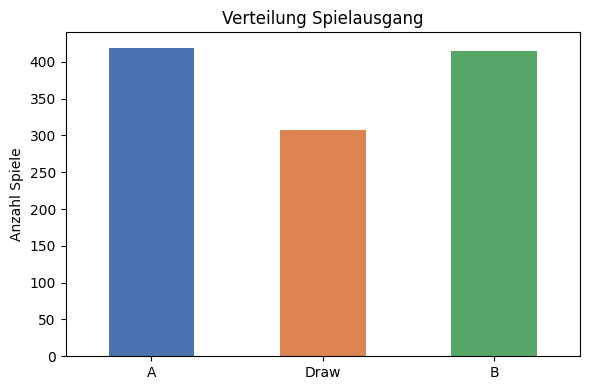

result
A       36.7
B       36.4
Draw    26.9
Name: proportion, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
df["result"].value_counts().reindex(["A", "Draw", "B"]).plot(
    kind="bar", ax=ax, color=["#4C72B0", "#DD8452", "#55A868"]
)
ax.set_title("Verteilung Spielausgang")
ax.set_xlabel("")
ax.set_ylabel("Anzahl Spiele")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(df["result"].value_counts(normalize=True).round(3) * 100)

---

### **6) Feature-Verteilungen nach Ergebnis**
Zeigt, ob Kern-Features (Ranking-Differenz, Formkurve) tatsächlich mit dem Ausgang zusammenhängen.

C:\Users\rodri\AppData\Local\Temp\ipykernel_40748\2683602622.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\rodri\AppData\Local\Temp\ipykernel_40748\2683602622.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\rodri\AppData\Local\Temp\ipykernel_40748\2683602622.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


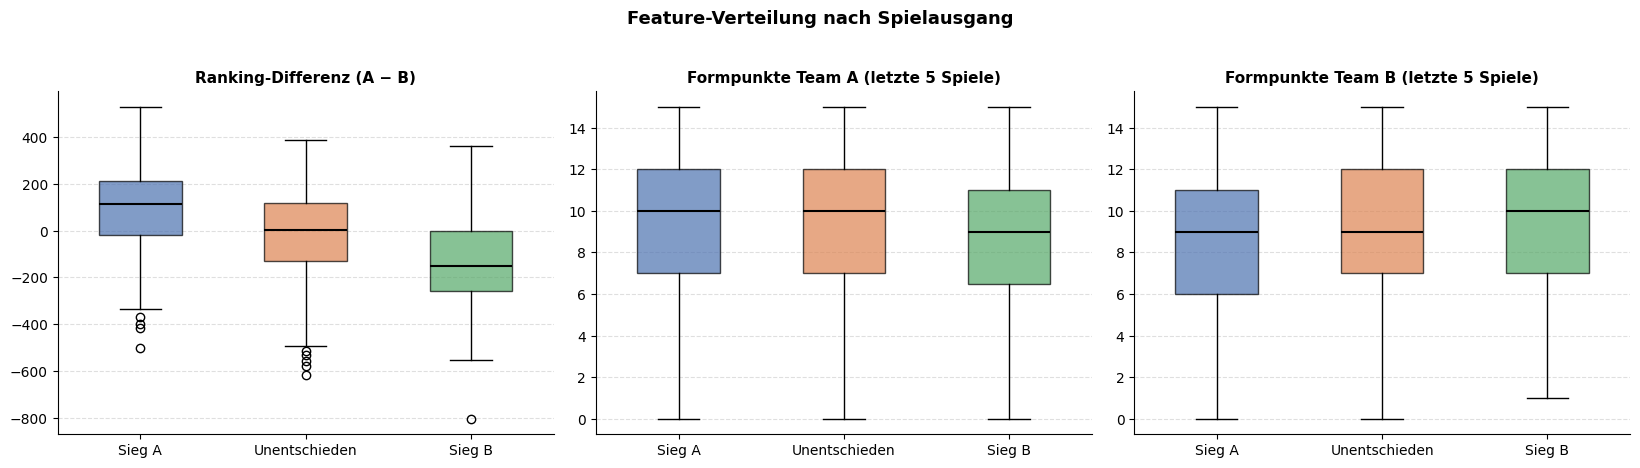

In [6]:
check_cols = ["ranking_diff", "a_form_points", "b_form_points"]
titles = {
    "ranking_diff": "Ranking-Differenz (A − B)",
    "a_form_points": "Formpunkte Team A (letzte 5 Spiele)",
    "b_form_points": "Formpunkte Team B (letzte 5 Spiele)",
}
result_order = ["A", "Draw", "B"]
colors = {"A": "#4C72B0", "Draw": "#DD8452", "B": "#55A868"}

fig, axes = plt.subplots(1, len(check_cols), figsize=(5.5 * len(check_cols), 4.5))

for ax, col in zip(axes, check_cols):
    data = [df.loc[df["result"] == r, col].dropna() for r in result_order]
    bp = ax.boxplot(
        data,
        labels=["Sieg A", "Unentschieden", "Sieg B"],
        patch_artist=True,
        widths=0.5,
        medianprops={"color": "black", "linewidth": 1.5},
    )
    for patch, r in zip(bp["boxes"], result_order):
        patch.set_facecolor(colors[r])
        patch.set_alpha(0.7)

    ax.set_title(titles[col], fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Feature-Verteilung nach Spielausgang", fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

---

### **7) Korrelationen zwischen Features**
Hilft, redundante Features zu erkennen (z.B. falls `ranking_a`/`ranking_b` stark mit anderen Features korrelieren).

In [7]:
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "fixture_id"]
corr = df[numeric_cols].corr()

# Statt einer unübersichtlichen Matrix: nur die stärksten paarweisen Korrelationen als Liste
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

print("Top 15 stärkste Korrelationen zwischen Features:\n")
print(f"{'Feature 1':<25} {'Feature 2':<25} {'Korrelation':>12}")
print("-" * 64)
for (f1, f2), value in corr_pairs.head(15).items():
    print(f"{f1:<25} {f2:<25} {value:>12.2f}")

Top 15 stärkste Korrelationen zwischen Features:

Feature 1                 Feature 2                  Korrelation
----------------------------------------------------------------
a_form_games_count        b_form_games_count                0.93
h2h_games                 h2h_a_wins                        0.81
b_shots_total_avg         b_shots_on_goal_avg               0.79
a_shots_total_avg         a_shots_on_goal_avg               0.75
h2h_games                 h2h_a_draws                       0.73
a_form_points             a_goals_for_avg                   0.66
b_form_points             b_goals_for_avg                   0.66
a_form_points             a_goals_against_avg              -0.66
b_goals_for_avg           b_shots_on_goal_avg               0.66
h2h_games                 h2h_a_losses                      0.64
b_form_points             b_goals_against_avg              -0.63
b_possession_avg          b_shots_total_avg                 0.61
b_shots_total_avg         b_corners_avg 

---

### **8) Fehlende Werte pro Spalte**
\u00dcbersicht, welche Spalten wie viel Prozent fehlende Werte haben (v.a. Ballbesitz/Sch\u00fcsse/Ecken).

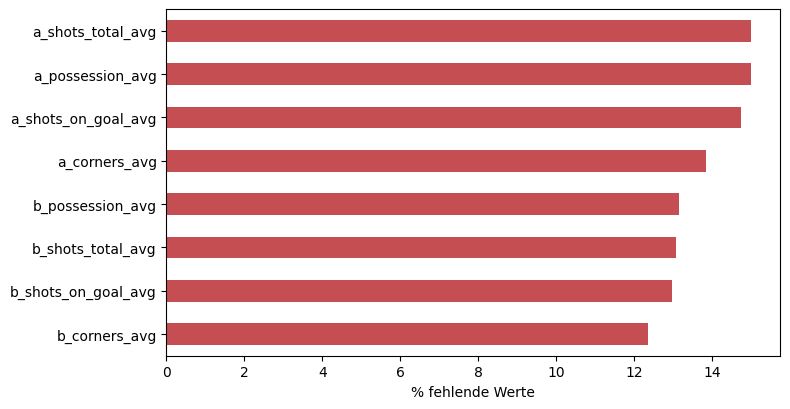

In [8]:
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

if len(missing_pct) == 0:
    print("Keine fehlenden Werte.")
else:
    fig, ax = plt.subplots(figsize=(8, 0.4 * len(missing_pct) + 1))
    missing_pct.plot(kind="barh", ax=ax, color="#C44E52")
    ax.set_xlabel("% fehlende Werte")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

---

### **9) Modell-Evaluation**
L\u00e4dt das trainierte Modell und wertet es auf demselben chronologischen Test-Split aus
wie `train_model.py` (damit die Zahlen konsistent bleiben).

In [9]:
model = joblib.load(MODELS_DIR / "random_forest_model.pkl")
imputer = joblib.load(MODELS_DIR / "imputer.pkl")
feature_cols = json.loads((MODELS_DIR / "feature_columns.json").read_text(encoding="utf-8"))

split_idx = int(len(df) * 0.8)
test_df = df.iloc[split_idx:]
X_test = test_df[feature_cols]
y_test = test_df["result"]

X_test_imp = imputer.transform(X_test)
y_pred = model.predict(X_test_imp)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           A       0.54      0.62      0.57        81
           B       0.50      0.73      0.59        79
        Draw       0.35      0.10      0.16        69

    accuracy                           0.50       229
   macro avg       0.46      0.48      0.44       229
weighted avg       0.47      0.50      0.46       229



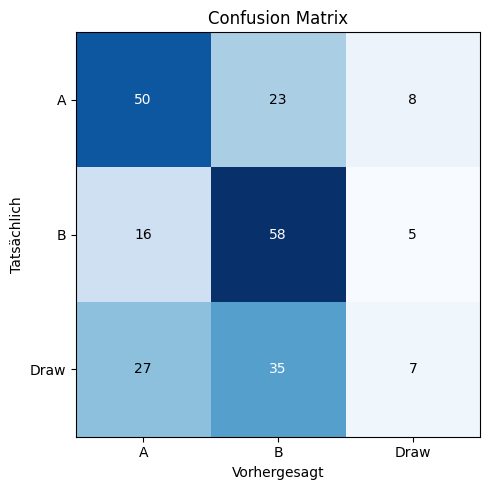

In [10]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel("Vorhergesagt")
ax.set_ylabel("Tats\u00e4chlich")
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

---

### **10) Feature Importance**
Welche Features beeinflussen die Vorhersage des Random-Forest-Modells am st\u00e4rksten?

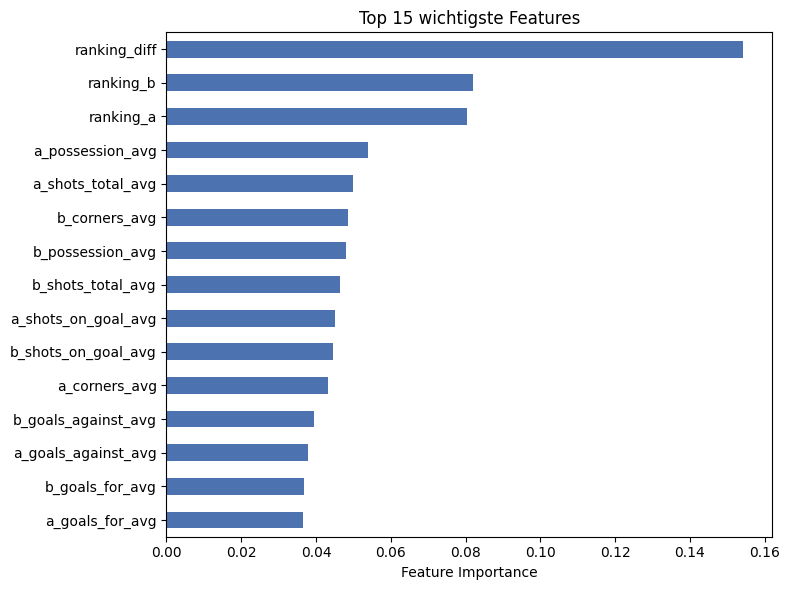

In [11]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importances.head(15).plot(kind="barh", ax=ax, color="#4C72B0")
plt.gca().invert_yaxis()
ax.set_xlabel("Feature Importance")
ax.set_title("Top 15 wichtigste Features")
plt.tight_layout()
plt.show()

---

### **11) Einzelne Vorhersage testen**
Simuliert, was das Streamlit-Dashboard später tun wird: zwei Teams auswählen, aktuelle
Formkurve/Ranking/H2H berechnen (als heutiges Datum, nicht historisch), Vorhersage abrufen.

In [12]:
from build_features import (
    load_team_id_cache, load_ranking_ratings, get_ranking,
    build_team_match_history, compute_rolling_features, compute_h2h,
)

team_id_cache = load_team_id_cache()
id_to_fifa_name = {v: k for k, v in team_id_cache.items()}
ranking_by_year = load_ranking_ratings()


def predict_matchup(team_a: str, team_b: str, as_of_date: str = "2026-07-14"):
    """Berechnet Features 'as of heute' für zwei Teams und gibt die
    Modell-Wahrscheinlichkeiten zurück (Vorschau auf die Dashboard-Logik)."""
    own_id_a = team_id_cache[team_a]
    own_id_b = team_id_cache[team_b]
    hist_a = build_team_match_history(team_a, own_id_a, id_to_fifa_name)
    hist_b = build_team_match_history(team_b, own_id_b, id_to_fifa_name)

    feat_a = compute_rolling_features(hist_a, as_of_date)
    feat_b = compute_rolling_features(hist_b, as_of_date)
    if feat_a is None or feat_b is None:
        print("Zu wenig Historie für eines der beiden Teams.")
        return None

    h2h = compute_h2h(hist_a, team_b, as_of_date)
    year = int(as_of_date[:4])
    ranking_a = get_ranking(ranking_by_year, team_a, year)
    ranking_b = get_ranking(ranking_by_year, team_b, year)

    row = {"a_is_home": True}
    row.update({f"a_{k}": v for k, v in feat_a.items()})
    row.update({f"b_{k}": v for k, v in feat_b.items()})
    row.update(h2h)
    row["ranking_a"] = ranking_a
    row["ranking_b"] = ranking_b
    row["ranking_diff"] = (ranking_a - ranking_b) if (ranking_a is not None and ranking_b is not None) else None

    X_new = pd.DataFrame([row])[feature_cols]
    X_new_imp = imputer.transform(X_new)
    proba = model.predict_proba(X_new_imp)[0]
    return dict(zip(model.classes_, proba))


# Beispiel - hier Teamnamen anpassen und ausprobieren:
result = predict_matchup("Canada", "Mexico")
if result:
    print("Vorhersage Canada (A) vs. Mexico (B):")
    for outcome, prob in sorted(result.items(), key=lambda x: -x[1]):
        label = {"A": "Sieg Canada", "B": "Sieg Mexico", "Draw": "Unentschieden"}[outcome]
        print(f"  {label:<16} {prob*100:5.1f}%")

Vorhersage Canada (A) vs. Mexico (B):
  Sieg Mexico       43.6%
  Sieg Canada       28.2%
  Unentschieden     28.1%
